# eda para previsão de custos médicos

**objetivo:** entender o comportamento da variável `charges` e identificar quais atributos explicam melhor o custo do seguro médico antes de construir o baseline de regressão linear.

**dataset:** `insurance.csv` (`Medical Cost Personal Datasets`, Kaggle)

**investigação:**
1. o dataset está íntegro para modelagem?
2. como as variáveis numéricas e categóricas estão distribuídas?
3. a target `charges` é simétrica ou precisa de transformação?
4. quais variáveis têm maior relação com `charges`?
5. existem sinais de interação importante entre IMC e tabagismo?
6. como os casos de alto custo se comportam?

## roteiro da análise

1. carga dos dados e visão geral
2. qualidade dos dados: tipos, nulos, duplicatas e valores inválidos
3. estatísticas descritivas e distribuição das variáveis
4. análise detalhada da variável-alvo `charges`
5. relações entre atributos e target, com correlação e testes estatísticos
6. interação entre IMC e tabagismo e perfil dos casos de alto custo
7. inferência estatística complementar

In [1]:
import warnings

import colorsys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

def pastel_equal_lightness(n=8, lightness=0.78, saturation=0.42):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [colorsys.hls_to_rgb(float(h), lightness, saturation) for h in hues]

PASTEL_CYCLE = pastel_equal_lightness(n=8, lightness=0.78, saturation=0.42)

PALETTE_SMOKER = {"no": "#A9D6E5", "yes": "#F2B5D4"}
PALETTE_SEX = {"female": "#C7CEEA", "male": "#B5EAD7"}
PALETTE_REGION = {
    "southeast": "#FFD6A5",
    "southwest": "#FDFFB6",
    "northwest": "#CAE9FF",
    "northeast": "#E4C1F9",
}
NUMERIC_COLORS = {
    "age": "#A9D6E5",
    "bmi": "#F4C2C2",
    "children": "#B5EAD7",
    "charges": "#C7CEEA",
    "log_charges": "#FFD6A5",
}

sns.set_theme(style="whitegrid")
sns.set_palette(PASTEL_CYCLE)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_CYCLE)
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df_raw = pd.read_csv("../data/insurance.csv").copy()
raw_rows = len(df_raw)

df = df_raw.drop_duplicates().copy()
removed_duplicates = raw_rows - len(df)

df["smoker_yes"] = (df["smoker"] == "yes").astype(int)
df["log_charges"] = np.log1p(df["charges"])

display(
    df.head().style.set_table_styles([
        {"selector": "table", "props": [("width", "100%"), ("display", "table")]},
    ])
)
print(f"duplicatas removidas para análise: {removed_duplicates}")

,age,sex,bmi,children,smoker,region,charges,smoker_yes,log_charges
0,19,female,27.900000,0,yes,southwest,16884.924000,1,9.734236
1,18,male,33.770000,1,no,southeast,1725.552300,0,7.453882
2,28,male,33.000000,3,no,southeast,4449.462000,0,8.400763
3,33,male,22.705000,0,no,northwest,21984.470610,0,9.998137
4,32,male,28.880000,0,no,northwest,3866.855200,0,8.260455


duplicatas removidas para análise: 1


## 1. visão geral do dataset

In [3]:
print(f"linhas no arquivo bruto: {len(df_raw)}")
print(f"linhas após remoção de duplicatas: {df.shape[0]}")
print(f"colunas: {df.shape[1]}")
print()
print(f"colunas: {list(df.columns)}")
print("tipos das variáveis:")
print(df.dtypes)

linhas no arquivo bruto: 1338
linhas após remoção de duplicatas: 1337
colunas: 9

colunas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'smoker_yes', 'log_charges']
tipos das variáveis:
age              int64
sex             object
bmi            float64
children         int64
smoker          object
region          object
charges        float64
smoker_yes       int64
log_charges    float64
dtype: object


## 2. qualidade dos dados

validação de ausência de valores faltantes, duplicatas e valores impossíveis em variáveis que representam idade, imc, número de filhos e custo


In [4]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values(by="missing", ascending=False)

duplicates = df_raw.duplicated().sum()
invalid_rows = df.query("age <= 0 or bmi <= 0 or children < 0 or charges <= 0")

display(
    quality_report.style.set_table_styles([
        {"selector": "table", "props": [("width", "100%"), ("display", "table")]},
    ])
)
print(f"duplicatas exatas: {duplicates}")
print(f"registros com valores inválidos pelas regras de negócio: {invalid_rows.shape[0]}")
display(invalid_rows.head())

,dtype,missing,missing_pct,unique_values
age,int64,0,0.000000,47
sex,object,0,0.000000,2
bmi,float64,0,0.000000,548
children,int64,0,0.000000,6
smoker,object,0,0.000000,2
region,object,0,0.000000,4
charges,float64,0,0.000000,1337
smoker_yes,int64,0,0.000000,2
log_charges,float64,0,0.000000,1337


duplicatas exatas: 1
registros com valores inválidos pelas regras de negócio: 0


,age,sex,bmi,children,smoker,region,charges,smoker_yes,log_charges


In [5]:
# quantidade de pessoas/registros por número de filhos
df["children"].value_counts().sort_index()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [6]:
pd.crosstab(df["age"], df["children"])

children,0,1,2,3,4,5
age,,,,,,
18,51,9,6,2,1,0
19,49,11,5,1,0,1
20,17,6,3,1,0,2
21,16,5,5,1,1,0
22,18,4,2,4,0,0
23,13,6,5,4,0,0
24,23,1,1,2,1,0
25,12,6,4,3,2,1
26,10,9,7,1,1,0


## 3. estatísticas descritivas

resumo das variáveis numéricas e da frequência das variáveis categóricas para entender escala, dispersão e balanceamento dos grupos


In [7]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

display(df[numeric_cols].describe().T)

for col in categorical_cols:
    freq = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )
    freq["pct"] = (freq["count"] / len(df) * 100).round(2)
    display(freq)

,count,mean,std,min,25%,50%,75%,max
age,"1,337.00",39.22,14.04,18.00,27.00,39.00,51.00,64.00
bmi,"1,337.00",30.66,6.10,15.96,26.29,30.40,34.70,53.13
children,"1,337.00",1.10,1.21,0.00,0.00,1.00,2.00,5.00
charges,"1,337.00","13,279.12","12,110.36","1,121.87","4,746.34","9,386.16","16,657.72","63,770.43"


,sex,count,pct
0,male,675,50.49
1,female,662,49.51


,smoker,count,pct
0,no,1063,79.51
1,yes,274,20.49


,region,count,pct
0,southeast,364,27.23
1,southwest,325,24.31
2,northwest,324,24.23
3,northeast,324,24.23


`age`: mediana 39, faixa 18–64, distribuição adulta bem ampla<br>
`bmi`: média 30.66 (acima de 30), indicando presença forte de sobrepeso/obesidade<br>
`children`: mediana 1 e Q3=2, então a maioria tem até 2 filhos<br>
`charges`: média (13.270) bem maior que a mediana (9.382) + máximo muito alto (63.770) e std grande, sinal de assimetria à direita e outliers<br>
`sex` está quase balanceado (50.5% vs 49.5%)<br>
`smoker` é desbalanceado (20.5% fumantes, 79.5% não fumantes)<br>
`region` está bem equilibrada (~24%–27% cada)<br>
`charges` é muito assimétrica, faz sentido testar log_charges e smoker é minoria, então vale manter split estratificado por smoker no treino/teste<br>

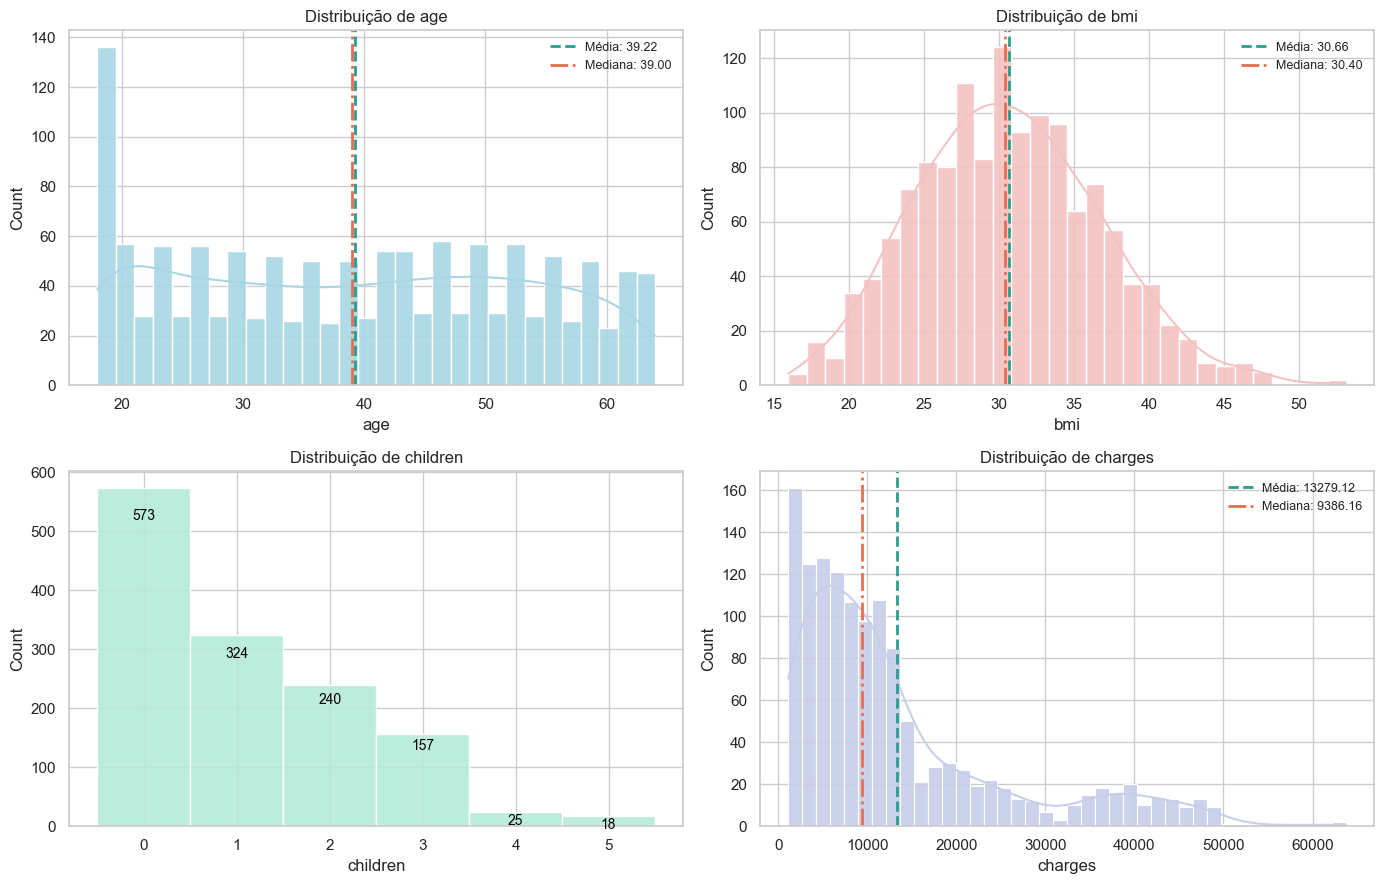

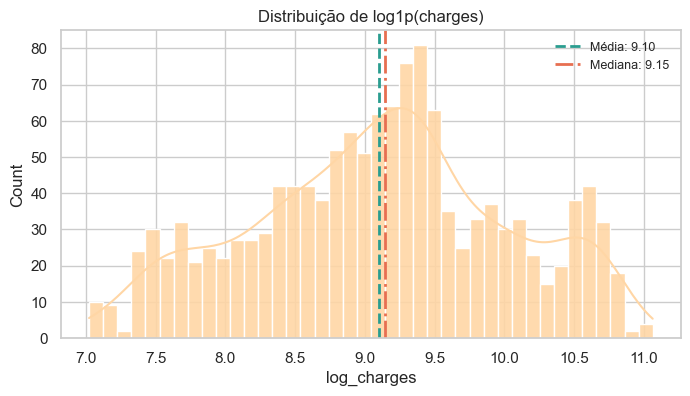

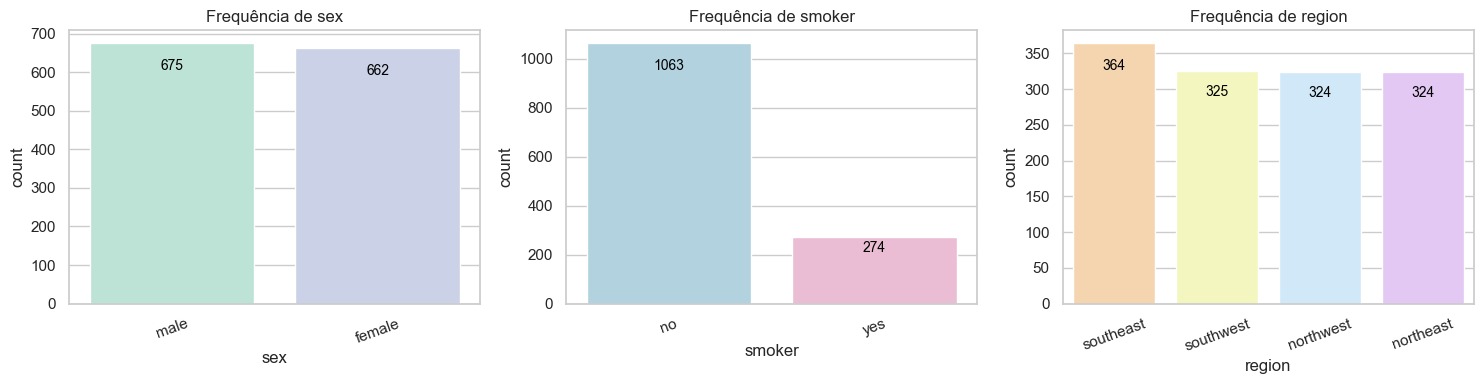

In [8]:
def add_count_labels_inside(ax, fontsize=10, color="black", frac=0.06):
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h) or h <= 0:
            continue
        y = h - max(h * frac, 4)
        ax.annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width() / 2, y),
            ha="center",
            va="top",
            fontsize=fontsize,
            color=color,
        )

def add_mean_median_lines(ax, s, mean_color="#2A9D8F", median_color="#E76F51"):
    mean_v = s.mean()
    median_v = s.median()
    ax.axvline(mean_v, color=mean_color, linestyle="--", linewidth=2, label=f"Média: {mean_v:.2f}")
    ax.axvline(median_v, color=median_color, linestyle="-.", linewidth=2, label=f"Mediana: {median_v:.2f}")
    ax.legend(frameon=False, fontsize=9)

numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    if col == "children":
        sns.histplot(
            df[col],
            discrete=True,
            kde=False,
            color=NUMERIC_COLORS[col],
            edgecolor="white",
            alpha=0.9,
            ax=ax,
        )
        add_count_labels_inside(ax)
    else:
        sns.histplot(
            df[col],
            bins=30 if col != "charges" else 40,
            kde=True,
            color=NUMERIC_COLORS[col],
            edgecolor="white",
            alpha=0.9,
            ax=ax,
        )
        add_mean_median_lines(ax, df[col])

    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    df["log_charges"],
    bins=40,
    kde=True,
    color=NUMERIC_COLORS["log_charges"],
    edgecolor="white",
    alpha=0.9,
)
add_mean_median_lines(plt.gca(), df["log_charges"])
plt.title("Distribuição de log1p(charges)")
plt.xlabel("log_charges")
plt.show()

palette_map = {
    "sex": PALETTE_SEX,
    "smoker": PALETTE_SMOKER,
    "region": PALETTE_REGION,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(
        data=df,
        x=col,
        order=order,
        hue=col,
        palette=palette_map[col],
        legend=False,
        ax=ax,
    )
    add_count_labels_inside(ax)
    ax.set_title(f"Frequência de {col}")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

`charges` é fortemente assimétrica à direita (média 13.279 bem acima da mediana 9.386), com cauda longa de alto custo<br>
`log_charges` fica muito mais “comportada” (média e mediana próximas), então faz sentido modelar também na escala log<br>
`children` é concentrada em 0–2 filhos (especialmente 0), com poucos casos em 4 e 5. faixas altas têm pouca amostra<br>
`age` está bem espalhada (18–64), com centro perto de 39. boa variabilidade para o modelo<br>
`bmi` concentra perto de 30 (limite sobrepeso/obesidade), sugerindo que IMC é relevante e pode ter efeito não linear/interação<br>
`smoker` está desbalanceado, então vale manter stratify por fumante no split<br>
`sex` está quase 50/50 e region quase uniforme, o que reduz risco de viés de amostragem por esses grupos<br>

n total: 1337
idades únicas: 47
esperado por idade (uniforme): 28.4
count age=18: 69


age
18    69
19    67
20    29
21    28
22    28
23    28
24    28
25    28
26    28
27    28
Name: count, dtype: int64

bmi                   children                     charges  \
           mean median  std count     mean median  std count      mean   
age_group                                                                
18        31.33  31.35 6.97    69     0.45   0.00 0.88    69  7,086.22   
19-64     30.63  30.30 6.05  1268     1.13   1.00 1.21  1268 13,616.12   

                                    
            median       std count  
age_group                           
18        2,198.19 10,198.46    69  
19-64     9,623.13 12,118.72  1268

smoker,no,yes
age_group,,
18,82.61,17.39
19-64,79.34,20.66


sex,female,male
age_group,,
18,47.83,52.17
19-64,49.61,50.39


Mann-Whitney U: 20123.00 | p-value: 3.933e-14


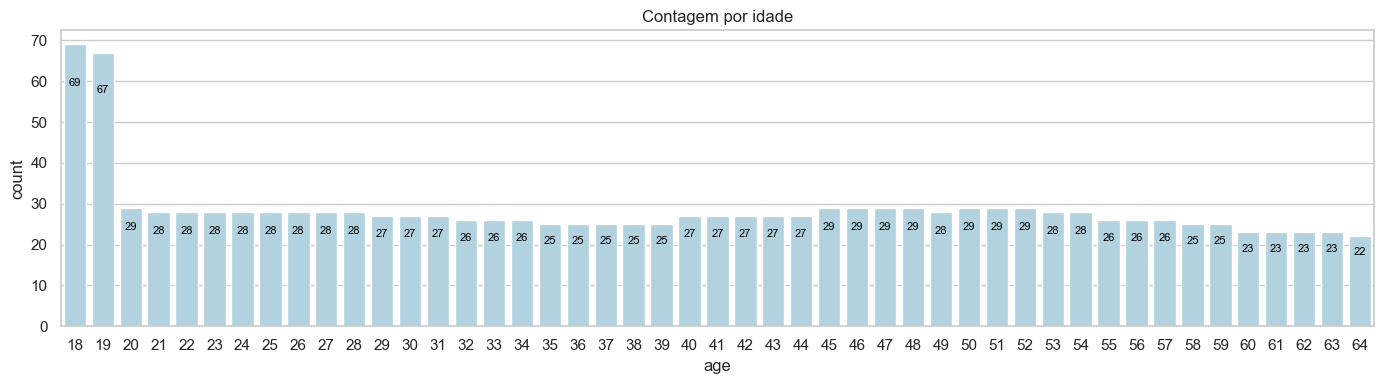

In [9]:
# magnitude do pico
age_counts = df["age"].value_counts().sort_index()
expected_uniform = len(df) / df["age"].nunique()

print(f"n total: {len(df)}")
print(f"idades únicas: {df['age'].nunique()}")
print(f"esperado por idade (uniforme): {expected_uniform:.1f}")
print(f"count age=18: {age_counts.loc[18]}")
display(age_counts.head(10))

# perfil: 18 vs demais
df["age_group"] = np.where(df["age"] == 18, "18", "19-64")

num_profile = (
    df.groupby("age_group")[["bmi", "children", "charges"]]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)
cat_profile_smoker = pd.crosstab(df["age_group"], df["smoker"], normalize="index").mul(100).round(2)
cat_profile_sex = pd.crosstab(df["age_group"], df["sex"], normalize="index").mul(100).round(2)

display(num_profile)
display(cat_profile_smoker)
display(cat_profile_sex)

# teste estatístico: charges(18) vs charges(19-64)
g18 = df.loc[df["age"] == 18, "charges"]
g_other = df.loc[df["age"] > 18, "charges"]

u_stat, p_val = stats.mannwhitneyu(g18, g_other, alternative="two-sided")
print(f"Mann-Whitney U: {u_stat:.2f} | p-value: {p_val:.3e}")

# gráfico
plt.figure(figsize=(14, 4))
ax = sns.barplot(x=age_counts.index, y=age_counts.values, color="#A9D6E5")

for p in ax.patches:
    h = p.get_height()
    if h <= 0:
        continue
    y = h - max(h * 0.12, 0.8)  # posição dentro da barra
    ax.annotate(
        f"{int(h)}",
        (p.get_x() + p.get_width() / 2, y),
        ha="center",
        va="top",
        fontsize=8,
        color="black"
    )

ax.set_title("Contagem por idade")
ax.set_xlabel("age")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

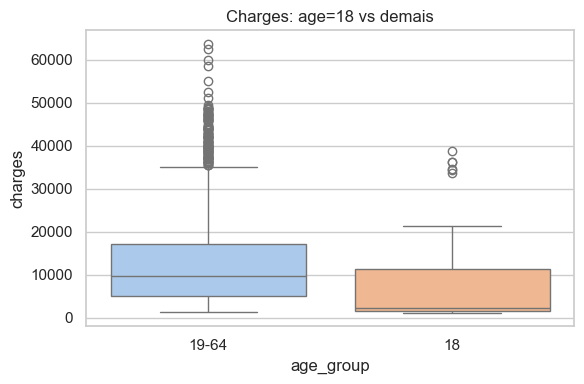

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="age_group", y="charges", palette="pastel")
plt.title("Charges: age=18 vs demais")
plt.tight_layout()
plt.show()

existe um pico de amostragem em 18 e 19 anos. esperado por idade seria ~28,4, mas aqui temos 69 (18) e 67 (19). isso pode sugerir distribuição etária não uniforme no dataset<br>
grupo 18 tem perfil diferente do restante:<br>
- `charges` muito menor (mediana 2.198 vs 9.623; média 7.086 vs 13.616)<br>
- menos filhos (mediana 0 vs 1)<br>
- menos fumantes (17,39% vs 20,66%)<br>
- sexo quase igual (não parece explicar a diferença)<br>
- o teste de Mann–Whitney (p = 3.93e-14) indica que a distribuição de charges em 18 vs 19-64 é estatisticamente diferente<br>
- mesmo com custo típico baixo em 18, há alguns outliers altos (boxplot), então não é um grupo “uniformemente barato”

## 4. variável-alvo `charges`
avaliação de assimetria, presença de outliers e o efeito de aplicar `log1p(charges)`

,metric,value
0,mean,"13,279.12"
1,median,"9,386.16"
2,std,"12,110.36"
3,cv_pct,91.20
4,skew(charges),1.52
5,kurtosis(charges),1.60
6,skew(log1p(charges)),-0.09
7,q1,"4,746.34"
8,q3,"16,657.72"
9,iqr,"11,911.37"


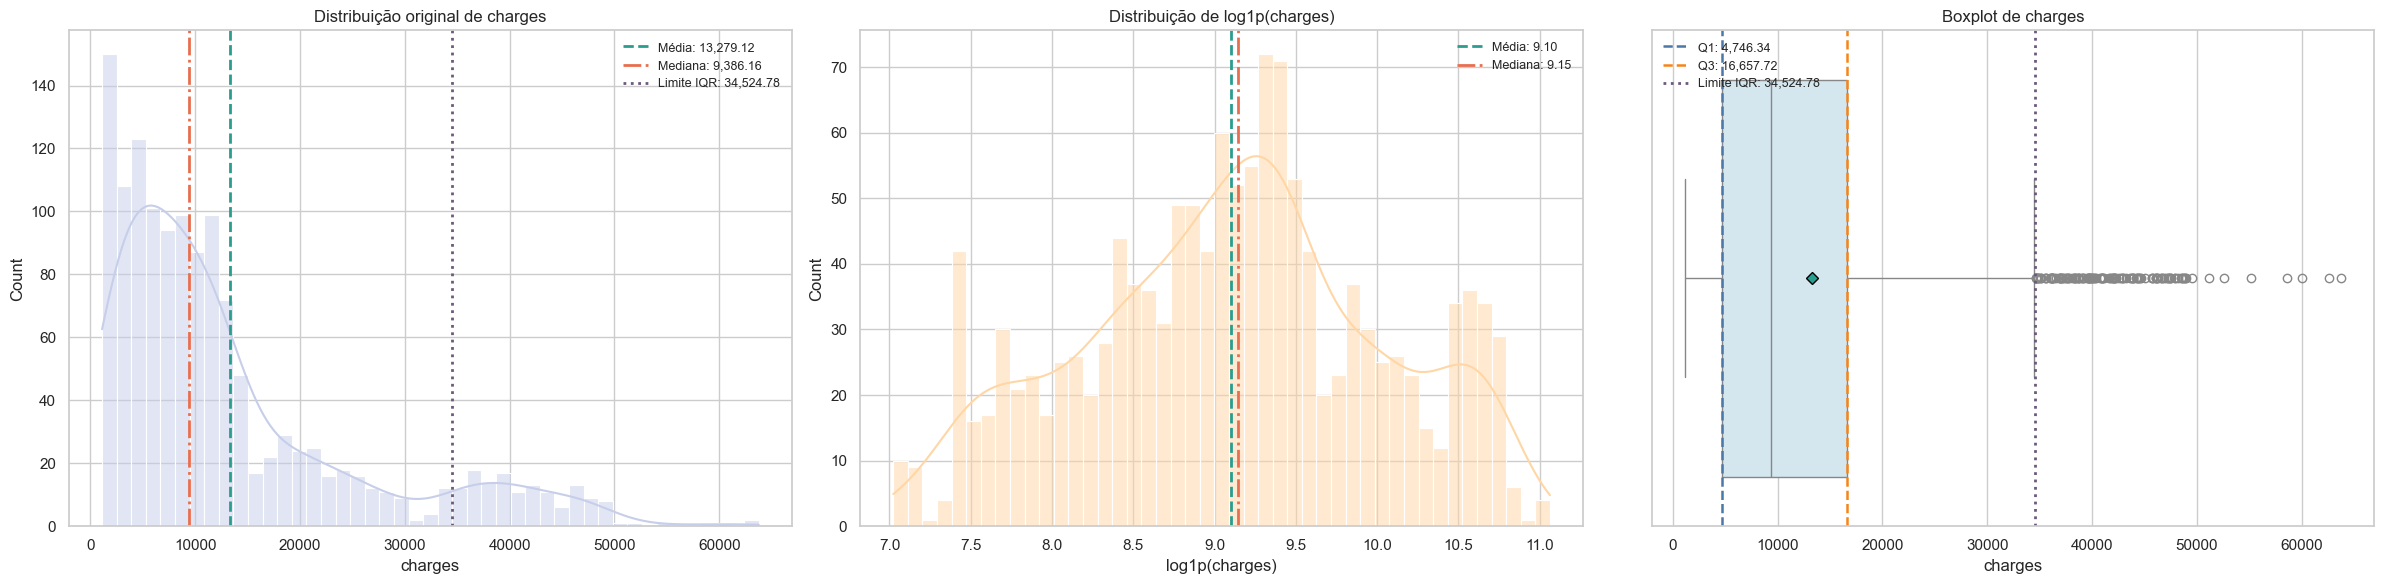

In [11]:
if "log_charges" not in df.columns:
    df["log_charges"] = np.log1p(df["charges"])

q1, q3 = df["charges"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

df["is_high_cost"] = df["charges"] > upper_limit

mean_raw = df["charges"].mean()
median_raw = df["charges"].median()
std_raw = df["charges"].std()

mean_log = df["log_charges"].mean()
median_log = df["log_charges"].median()

target_profile = pd.DataFrame({
    "metric": [
        "mean",
        "median",
        "std",
        "cv_pct",
        "skew(charges)",
        "kurtosis(charges)",
        "skew(log1p(charges))",
        "q1",
        "q3",
        "iqr",
        "p90",
        "p95",
        "outliers_acima_limite_iqr",
        "pct_outliers_iqr",
        "limite_inferior_iqr",
        "limite_superior_iqr",
    ],
    "value": [
        mean_raw,
        median_raw,
        std_raw,
        (std_raw / mean_raw) * 100,
        df["charges"].skew(),
        df["charges"].kurt(),
        df["log_charges"].skew(),
        q1,
        q3,
        iqr,
        df["charges"].quantile(0.90),
        df["charges"].quantile(0.95),
        df["is_high_cost"].sum(),
        df["is_high_cost"].mean() * 100,
        lower_limit,
        upper_limit,
    ],
})

target_profile["value"] = target_profile["value"].round(2)
display(target_profile)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# charges original
sns.histplot(
    df["charges"],
    bins=45,
    kde=True,
    color=NUMERIC_COLORS["charges"],
    edgecolor="white",
    ax=axes[0]
)
axes[0].axvline(mean_raw, color="#2A9D8F", linestyle="--", linewidth=2, label=f"Média: {mean_raw:,.2f}")
axes[0].axvline(median_raw, color="#E76F51", linestyle="-.", linewidth=2, label=f"Mediana: {median_raw:,.2f}")
axes[0].axvline(upper_limit, color="#6D597A", linestyle=":", linewidth=2, label=f"Limite IQR: {upper_limit:,.2f}")
axes[0].set_title("Distribuição original de charges")
axes[0].set_xlabel("charges")
axes[0].legend(frameon=False, fontsize=9)

# log1p(charges)
sns.histplot(
    df["log_charges"],
    bins=45,
    kde=True,
    color=NUMERIC_COLORS["log_charges"],
    edgecolor="white",
    ax=axes[1]
)
axes[1].axvline(mean_log, color="#2A9D8F", linestyle="--", linewidth=2, label=f"Média: {mean_log:.2f}")
axes[1].axvline(median_log, color="#E76F51", linestyle="-.", linewidth=2, label=f"Mediana: {median_log:.2f}")
axes[1].set_title("Distribuição de log1p(charges)")
axes[1].set_xlabel("log1p(charges)")
axes[1].legend(frameon=False, fontsize=9)

# boxplot charges
sns.boxplot(
    x=df["charges"],
    ax=axes[2],
    color="#D0E8F2",
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "#2A9D8F", "markeredgecolor": "black", "markersize": 6}
)
axes[2].axvline(q1, color="#4C78A8", linestyle="--", linewidth=1.8, label=f"Q1: {q1:,.2f}")
axes[2].axvline(q3, color="#F58518", linestyle="--", linewidth=1.8, label=f"Q3: {q3:,.2f}")
axes[2].axvline(upper_limit, color="#6D597A", linestyle=":", linewidth=2, label=f"Limite IQR: {upper_limit:,.2f}")
axes[2].set_title("Boxplot de charges")
axes[2].set_xlabel("charges")
axes[2].legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

`mean` = 13.270 e median = 9.382: média bem maior que mediana, sinal de cauda à direita<br>
`std` = 12.110: alta dispersão dos custos<br>
`skew(charges)` = 1.52: assimetria positiva forte (distribuição “puxada” para valores altos)<br>
`skew(log1p(charges))` = -0.09: após log, a distribuição fica quase simétrica<br>
`limite_superior_iqr` = 34.489: acima disso o método IQR marca como outlier<br>
`outliers_acima_limite_iqr` = 139 (10.39%): proporção relevante de custos muito altos<br>
`charges` original tem cauda longa e muitos extremos<br>
outliers podem representar casos reais caros (especialmente fumantes). comparar de modelos (com e sem log) para decidir

## 5. relação das variáveis com a target

medir a associação linear entre as variáveis e `charges`
- para `age`, `bmi` e `children`, usei correlação de Pearson
- para `smoker`, transformei em `smoker_yes` (0/1). nesse caso, o Pearson equivale à correlação ponto-bisserial
- também comparei com `log1p(charges)`, porque no baseline vou testar a target nas duas escalas (original e log)
- o **p-value** ajuda a validar se a associação observada é diferente de zero de forma estatisticamente significativa (não parece efeito aleatório)

,feature,pearson_r_charges,p_value_charges,pearson_r_log_charges,p_value_log_charges
3,smoker_yes,0.79,0.00,0.67,0.00
0,age,0.30,0.00,0.53,0.00
1,bmi,0.20,0.00,0.13,0.00
2,children,0.07,0.01,0.16,0.00


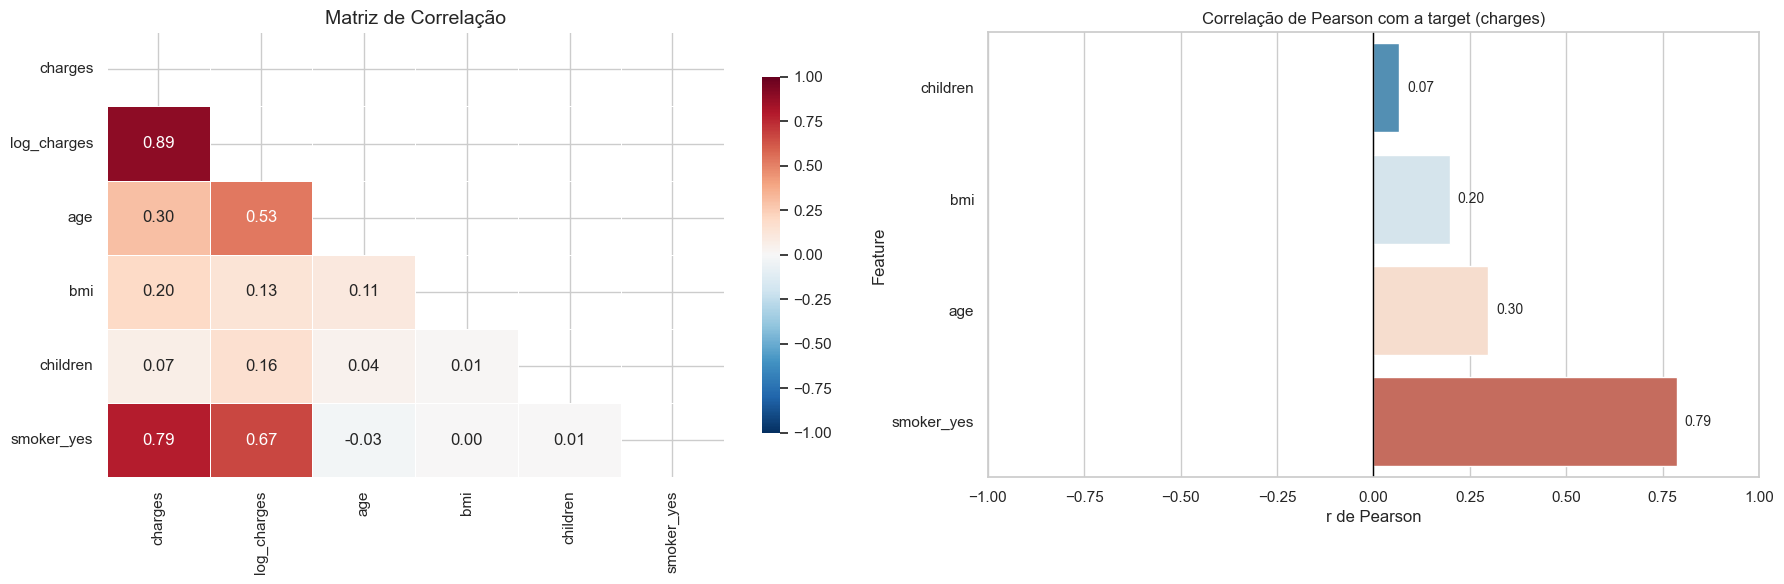

In [12]:
# garante coluna numérica para smoker
if "smoker_yes" not in df.columns:
    df["smoker_yes"] = (df["smoker"] == "yes").astype(int)

# tabela de associação
association_rows = []
for col in ["age", "bmi", "children", "smoker_yes"]:
    corr_raw, p_raw = stats.pearsonr(df[col], df["charges"])
    corr_log, p_log = stats.pearsonr(df[col], df["log_charges"])
    association_rows.append({
        "feature": col,
        "pearson_r_charges": corr_raw,
        "p_value_charges": p_raw,
        "pearson_r_log_charges": corr_log,
        "p_value_log_charges": p_log
    })

association_table = (
    pd.DataFrame(association_rows)
    .sort_values(by="pearson_r_charges", ascending=False)
)
display(association_table)

# dados para os gráficos
corr_matrix = df[["charges", "log_charges", "age", "bmi", "children", "smoker_yes"]].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

target = "charges"
features = ["age", "bmi", "children", "smoker_yes"]

rows = []
for f in features:
    r, p = stats.pearsonr(df[f], df[target])
    rows.append({"feature": f, "pearson_r": r, "p_value": p})

corr_target = pd.DataFrame(rows).sort_values("pearson_r", ascending=True)

# gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (1) heatmap triangular
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)
axes[0].set_title("Matriz de Correlação", fontsize=14)
axes[0].tick_params(axis="x", rotation=90)
axes[0].tick_params(axis="y", rotation=0)

# correlação com target
sns.barplot(
    data=corr_target,
    x="pearson_r",
    y="feature",
    palette="RdBu_r",
    ax=axes[1]
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(-1, 1)
axes[1].set_title("Correlação de Pearson com a target (charges)")
axes[1].set_xlabel("r de Pearson")
axes[1].set_ylabel("Feature")

for i, row in corr_target.reset_index(drop=True).iterrows():
    x = row["pearson_r"]
    axes[1].text(
        x + (0.02 if x >= 0 else -0.02),
        i,
        f"{x:.2f}",
        va="center",
        ha="left" if x >= 0 else "right",
        fontsize=10
    )

plt.tight_layout()
plt.show()

`smoker_yes` (r=0.79 com charges) é o preditor mais forte<br>
`age` (r=0.30) tem efeito moderado<br>
`bmi` (r=0.20) tem efeito fraco<br>
`children` (r=0.07) é efeito muito fraco (mesmo com p baixo, impacto pequeno)<br>
com `log_charges`, `age` sobe para r=0.53 e `children` para r=0.16, sugerindo que a transformação log melhora parte da estrutura linear<br>
entre preditores, as correlações são baixas (ex: `age` vs `bmi` ~0.11, `age` vs `smoker_yes` ~-0.03), o que é bom para multicolinearidade no baseline<br>
baseline faz sentido com `smoker_yes` + `age` + `bmi`<br>
`children` pode entrar como teste, mas expectativa de ganho é pequena<br>

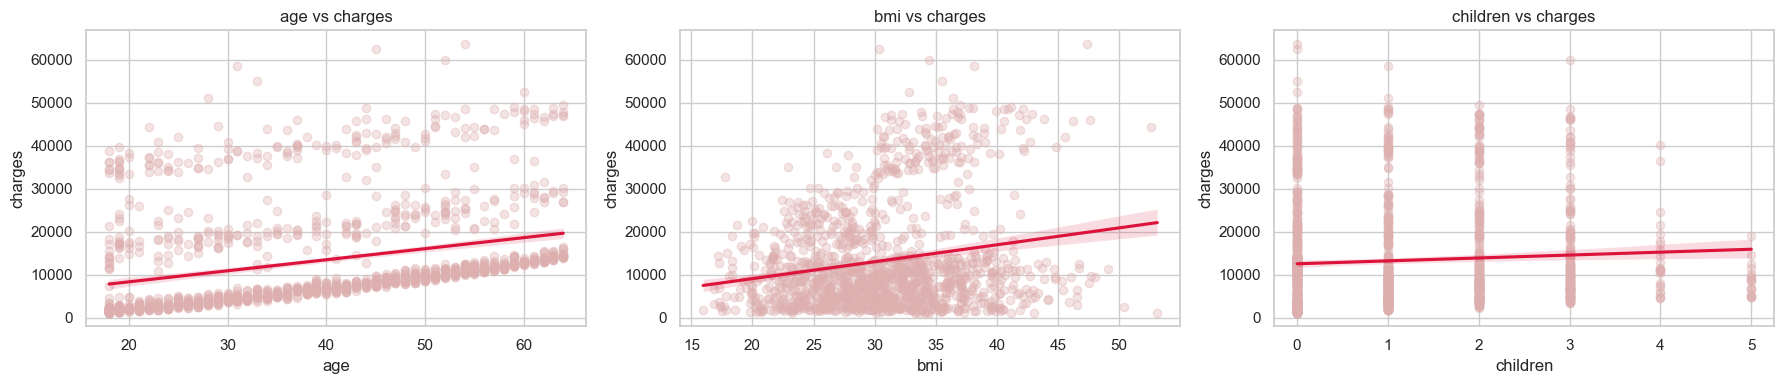

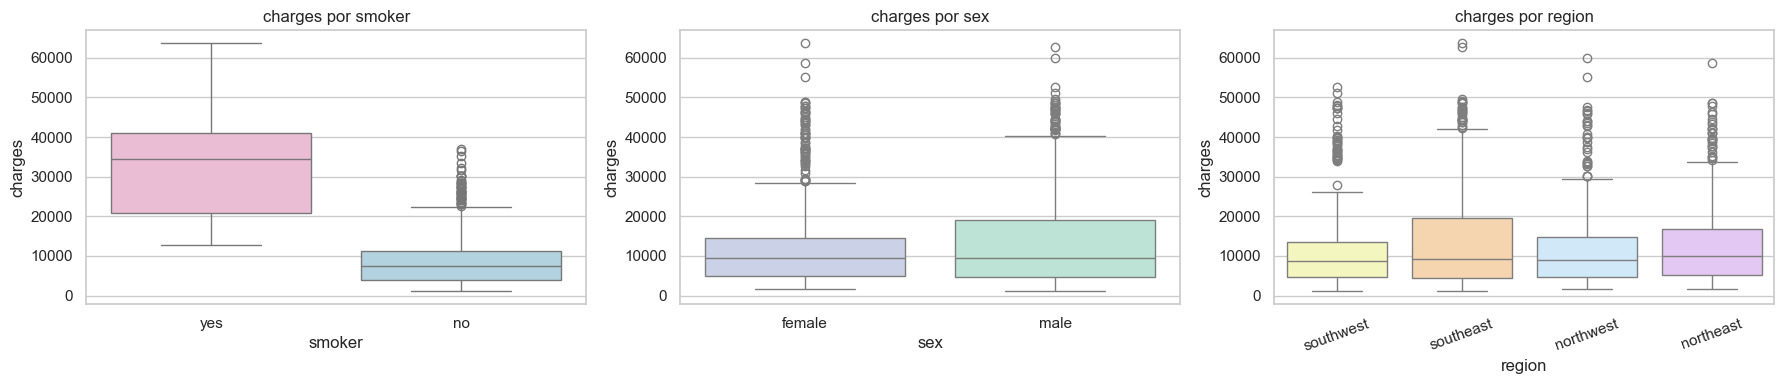

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, ["age", "bmi", "children"]):
    sns.regplot(
        data=df,
        x=col,
        y="charges",
        scatter_kws={"alpha": 0.35},
        line_kws={"color": "crimson"},
        ax=ax
    )
    ax.set_title(f"{col} vs charges")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", palette=PALETTE_SMOKER, legend=False, ax=axes[0])
axes[0].set_title("charges por smoker")

sns.boxplot(data=df, x="sex", y="charges", hue="sex", palette=PALETTE_SEX, legend=False, ax=axes[1])
axes[1].set_title("charges por sex")

sns.boxplot(data=df, x="region", y="charges", hue="region", palette=PALETTE_REGION, legend=False, ax=axes[2])
axes[2].set_title("charges por region")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

`age` vs `charges` tem tendência positiva clara. em média, custo sobe com idade, mas com bastante dispersão<br>
`bmi` vs `charges` tem tendência positiva mais fraca/moderada e bem espalhada. sozinho explica pouco<br>
`children` vs `charges` tem linha quase plana. efeito linear fraco<br>
`charges` por `smoker`: fumantes têm mediana e faixa inteira de custos muito acima dos não fumantes<br>
`charges` por `sex` tem distribuições parecidas. diferença pequena<br>
`charges` por `region` tem distribuições relativamente próximas; sem separação forte entre regiões<br>

### evidência por grupos categóricos

além da correlação, também vale comparar como `charges` se comporta entre os principais grupos
essa etapa ajuda a sustentar melhor as decisões do modelo. por que `smoker` entra no baseline como variável essencial e por que `sex` e `region` podem ficar para uma segunda iteração

,count,mean,median,std
smoker,,,,
no,1063,"8,440.66","7,345.73","5,992.97"
yes,274,"32,050.23","34,456.35","11,541.55"


,count,mean,median,std
sex,,,,
female,662,"12,569.58","9,412.96","11,128.70"
male,675,"13,975.00","9,377.90","12,971.96"


,count,mean,median,std
region,,,,
northeast,324,"13,406.38","10,057.65","11,255.80"
northwest,324,"12,450.84","8,976.98","11,073.13"
southeast,364,"14,735.41","9,294.13","13,971.10"
southwest,325,"12,346.94","8,798.59","11,557.18"


,comparison,test,statistic,p_value
0,smoker=yes vs smoker=no,Welch t-test,32.74,0.00
1,sex=female vs sex=male,Welch t-test,-2.13,0.03
2,region groups,Kruskal-Wallis,4.62,0.20


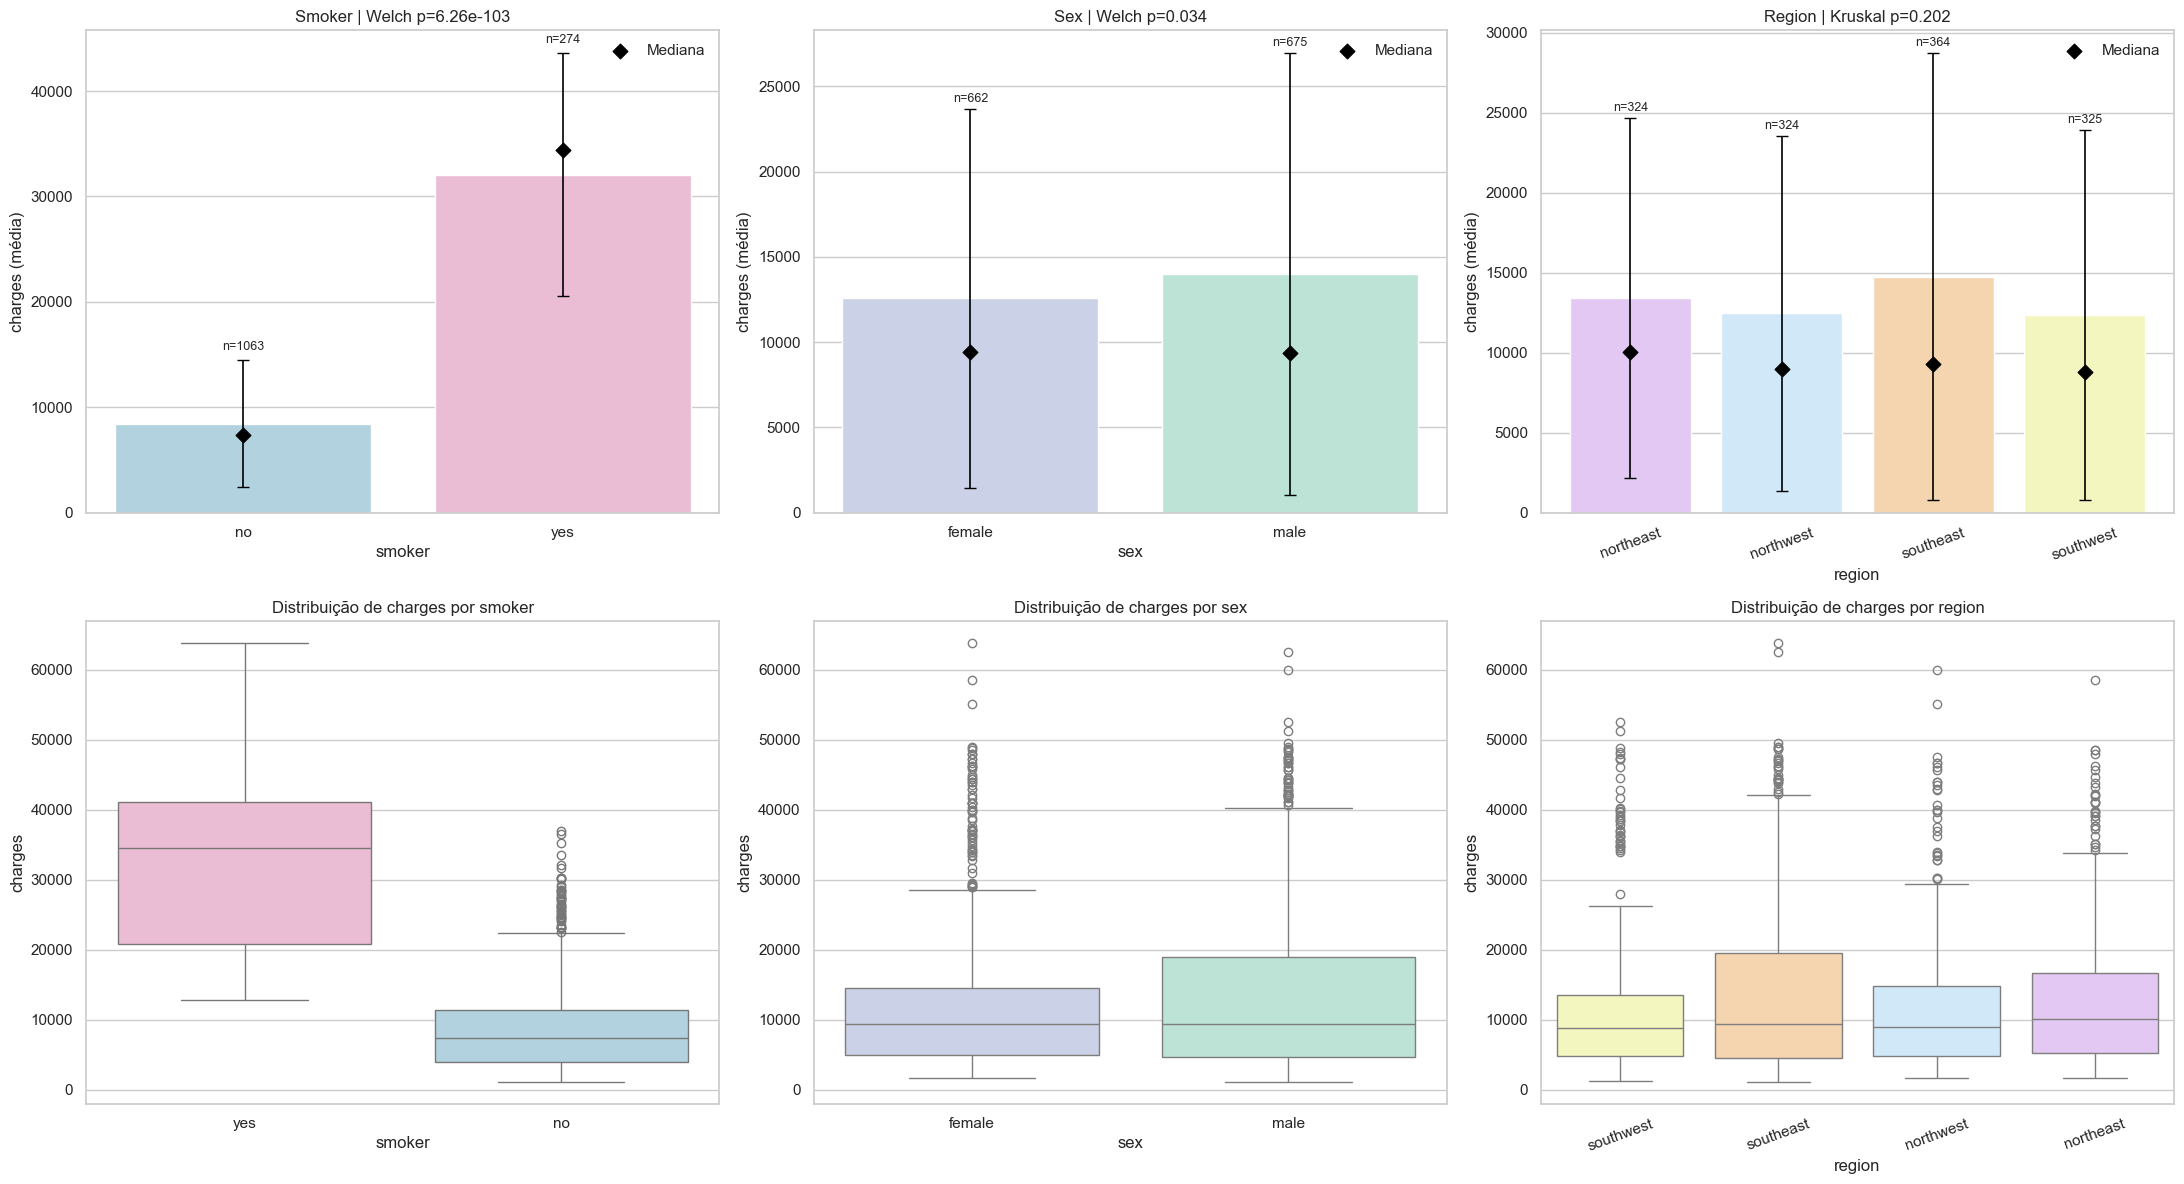

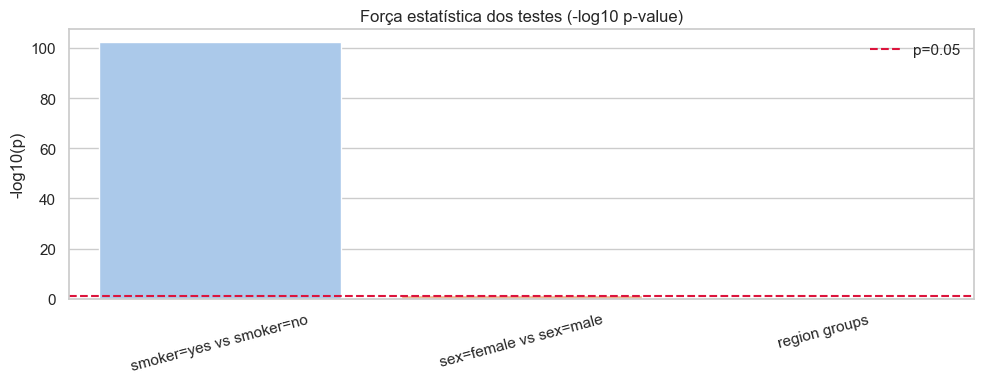

In [14]:
# resumos e testes
smoker_summary = df.groupby("smoker")["charges"].agg(["count", "mean", "median", "std"]).round(2)
sex_summary = df.groupby("sex")["charges"].agg(["count", "mean", "median", "std"]).round(2)
region_summary = df.groupby("region")["charges"].agg(["count", "mean", "median", "std"]).round(2)

welch_smoker = stats.ttest_ind(
    df.loc[df["smoker"] == "yes", "charges"],
    df.loc[df["smoker"] == "no", "charges"],
    equal_var=False
)

welch_sex = stats.ttest_ind(
    df.loc[df["sex"] == "female", "charges"],
    df.loc[df["sex"] == "male", "charges"],
    equal_var=False
)

kruskal_region = stats.kruskal(*[g["charges"].values for _, g in df.groupby("region")])

categorical_tests = pd.DataFrame([
    {"comparison": "smoker=yes vs smoker=no", "test": "Welch t-test", "statistic": welch_smoker.statistic, "p_value": welch_smoker.pvalue},
    {"comparison": "sex=female vs sex=male", "test": "Welch t-test", "statistic": welch_sex.statistic, "p_value": welch_sex.pvalue},
    {"comparison": "region groups", "test": "Kruskal-Wallis", "statistic": kruskal_region.statistic, "p_value": kruskal_region.pvalue},
])

display(smoker_summary)
display(sex_summary)
display(region_summary)
display(categorical_tests)

# paletas
PALETTE_SMOKER = {"no": "#A9D6E5", "yes": "#F2B5D4"}
PALETTE_SEX = {"female": "#C7CEEA", "male": "#B5EAD7"}
PALETTE_REGION = {"southeast": "#FFD6A5", "southwest": "#FDFFB6", "northwest": "#CAE9FF", "northeast": "#E4C1F9"}

# gráficos: médias/medianas + distribuição
def plot_mean_std_median(ax, summary_df, group_col, palette, title):
    plot_df = summary_df.reset_index().rename(columns={summary_df.index.name: group_col})
    order = plot_df[group_col].tolist()

    sns.barplot(
        data=plot_df, x=group_col, y="mean",
        order=order, palette=palette, ax=ax, edgecolor="white"
    )

    x = np.arange(len(plot_df))
    ax.errorbar(
        x=x, y=plot_df["mean"], yerr=plot_df["std"],
        fmt="none", c="black", capsize=4, linewidth=1.2
    )

    ax.scatter(x, plot_df["median"], marker="D", s=55, color="black", label="Mediana", zorder=3)

    offset = max(plot_df["mean"].max() * 0.03, 300)
    for i, row in plot_df.iterrows():
        ax.text(i, row["mean"] + row["std"] + offset, f"n={int(row['count'])}", ha="center", fontsize=9)

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel("charges (média)")
    ax.legend(frameon=False)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# linha 1: média + desvio + mediana
plot_mean_std_median(
    axes[0, 0], smoker_summary, "smoker", PALETTE_SMOKER,
    f"Smoker | Welch p={welch_smoker.pvalue:.2e}"
)
plot_mean_std_median(
    axes[0, 1], sex_summary, "sex", PALETTE_SEX,
    f"Sex | Welch p={welch_sex.pvalue:.3f}"
)
plot_mean_std_median(
    axes[0, 2], region_summary, "region", PALETTE_REGION,
    f"Region | Kruskal p={kruskal_region.pvalue:.3f}"
)
axes[0, 2].tick_params(axis="x", rotation=20)

# linha 2: boxplots (distribuição)
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", palette=PALETTE_SMOKER, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Distribuição de charges por smoker")

sns.boxplot(data=df, x="sex", y="charges", hue="sex", palette=PALETTE_SEX, legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Distribuição de charges por sex")

sns.boxplot(data=df, x="region", y="charges", hue="region", palette=PALETTE_REGION, legend=False, ax=axes[1, 2])
axes[1, 2].set_title("Distribuição de charges por region")
axes[1, 2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# gráfico só dos p-values
tests_plot = categorical_tests.copy()
tests_plot["neg_log10_p"] = -np.log10(tests_plot["p_value"].clip(lower=1e-300))

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=tests_plot, x="comparison", y="neg_log10_p", palette="pastel")
ax.axhline(-np.log10(0.05), color="crimson", linestyle="--", linewidth=1.5, label="p=0.05")
ax.set_title("Força estatística dos testes (-log10 p-value)")
ax.set_xlabel("")
ax.set_ylabel("-log10(p)")
ax.tick_params(axis="x", rotation=15)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

`smoker` aparece como principal driver de custo
- média: 32.050 (fumante) vs 8.434 (não fumante)
- mediana também muito acima (34.456 vs 7.345)
- welch com p-value extremamente baixo (~5.9e-103), reforçando diferença real entre os grupos

`sex` mostra sinal mais fraco
- médias até diferem (13.957 vs 12.570), mas as medianas são bem próximas
- p-value ~0.036 indica diferença estatística, porém com impacto prático menor

`region` não traz evidência forte de separação
- há variação de médias (com southeast maior), mas com muita sobreposição nas distribuições
- kruskal com p-value ~0.192 (> 0.05), sem evidência estatística de diferença relevante entre regiões

a variabilidade de `charges` é alta em todos os grupos (std elevado + muitos outliers)

## 6. hipótese de interação: imc x tabagismo

correlação entre bmi_x_smoker e charges: 0.845
p-valor da interação: 0.000e+00


mean    median  count
bmi_bin    smoker                           
baixo peso no      5,485.06  4,249.32     16
           yes    18,809.82 15,006.58      5
normal     no      7,734.65  6,669.48    176
           yes    19,942.22 19,479.90     50
sobrepeso  no      8,226.09  7,046.72    311
           yes    22,491.18 21,348.71     75
obesidade  no      8,866.16  8,100.09    560
           yes    41,692.81 40,918.31    144

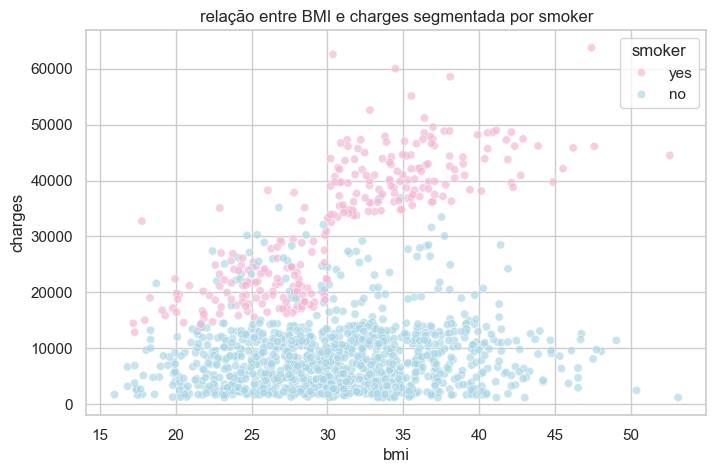

In [21]:
df["bmi_x_smoker"] = df["bmi"] * df["smoker_yes"]
df["bmi_bin"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, df["bmi"].max() + 1],
    labels=["baixo peso", "normal", "sobrepeso", "obesidade"],
    include_lowest=True
)

interaction_corr, interaction_p = stats.pearsonr(df["bmi_x_smoker"], df["charges"])
print(f"correlação entre bmi_x_smoker e charges: {interaction_corr:.3f}")
print(f"p-valor da interação: {interaction_p:.3e}")

bmi_smoker_summary = df.groupby(["bmi_bin", "smoker"], observed=False)["charges"].agg(["mean", "median", "count"]).round(2)
display(bmi_smoker_summary)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette=PALETTE_SMOKER, alpha=0.65)
plt.title("relação entre BMI e charges segmentada por smoker")
plt.show()

a correlação de `bmi_x_smoker` com `charges` ficou em 0.845, que é um sinal muito forte de interação entre imc e tabagismo
o p-value praticamente zero reforça que essa associação dificilmente é aleatória

quando segmentamos por faixa de imc, percebemos que fumantes têm custo sempre muito maior
na obesidade, por exemplo
- não fumante tem média ~8.9k
- fumante tem média ~41.7k

também dá para ver no scatter
- entre não fumantes, `charges` sobe mais devagar com imc
- entre fumantes, o crescimento é muito mais acentuado, tem inclinação maior

testar no modelo um termo de interação
- `charges ~ age + bmi + smoker_yes + bmi_x_smoker`

## 7. perfil dos casos de alto custo

como `charges` tem cauda longa, faz sentido investigar quem são os casos acima do limite do boxplot (iqr)<br>
essa leitura ajuda a identificar se estamos vendo apenas ruído/outlier aleatório ou se existe um padrão relevante de negócio entre os casos de alto custo

age                bmi              children              \
             count  mean median count  mean median    count mean median   
is_high_cost                                                              
False         1198 39.01  39.00  1198 30.09  29.74     1198 1.09   1.00   
True           139 41.08  43.00   139 35.56  35.20      139 1.19   1.00   

             charges                      
               count      mean    median  
is_high_cost                              
False           1198  9,934.67  8,411.75  
True             139 42,103.95 40,974.16

smoker,no,yes
is_high_cost,,
False,88.48,11.52
True,2.16,97.84


region,northeast,northwest,southeast,southwest
is_high_cost,,,,
False,24.71,25.38,25.63,24.29
True,20.14,14.39,41.01,24.46


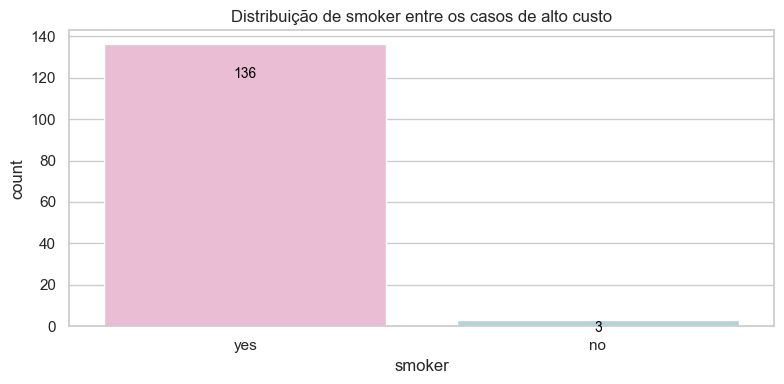

In [16]:
high_cost_numeric = (
    df.groupby("is_high_cost")[["age", "bmi", "children", "charges"]]
    .agg(["count", "mean", "median"])
    .round(2)
)

high_cost_categorical = pd.crosstab(
    df["is_high_cost"],
    df["smoker"],
    normalize="index"
).mul(100).round(2)

high_cost_region = pd.crosstab(
    df["is_high_cost"],
    df["region"],
    normalize="index"
).mul(100).round(2)

display(high_cost_numeric)
display(high_cost_categorical)
display(high_cost_region)

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=df[df["is_high_cost"]],
    x="smoker",
    hue="smoker",
    palette=PALETTE_SMOKER,
    legend=False
)

for p in ax.patches:
    h = p.get_height()
    if h <= 0:
        continue
    y = h - max(h * 0.08, 0.4)  # dentro da barra
    ax.annotate(
        f"{int(h)}",
        (p.get_x() + p.get_width() / 2, y),
        ha="center",
        va="top",
        fontsize=10,
        color="black"
    )

ax.set_title("Distribuição de smoker entre os casos de alto custo")
plt.tight_layout()
plt.show()

aqui temos a comparação entre dois grupos<br>
- `is_high_cost` = False: casos “normais”<br>
- `is_high_cost` = True: casos acima do limite IQR (alto custo)<br>

alto custo é minoria: 139 de 1338<br>

`charges`: aumento de valores<br>
- não alto custo: média ~9.9k, mediana ~8.4k<br>
- alto custo: média ~42.1k, mediana ~41.0k<br>

`age` e `bmi` são maiores no grupo alto custo<br>
- `age` média: 41.1 vs 39.0<br>
- `bmi` média: 35.6 vs 30.1<br>
perfil mais velho com IMC alto pode ser mais arriscado<br>

`children` muda pouco (1.19 vs 1.08), menor impacto<br>

`smoker` domina completamente os altos custos<br>
- entre altos custos, 97.84% são fumantes<br>
- entre não altos custos, só 11.51% são fumantes<br>

`region` mostra concentração em southeast no alto custo (41%)

## 8. inferência estatística

nesta seção, trouxe algumas inferências estatísticas para aprofundamento do eda

- tamanho de efeito (Cohen’s d) + intervalo de confiança via bootstrap para comparação entre grupos
- correlação de Spearman (mais robusta a outliers) em paralelo com Pearson
- correção de múltiplos testes com FDR/BH
- regressão OLS com erros robustos (HC3), incluindo a interação `bmi_x_smoker`
- teste de heterocedasticidade de Breusch-Pagan em `charges` e em `log_charges`

In [17]:
def cohen_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    if pooled == 0:
        return np.nan
    return (x.mean() - y.mean()) / pooled


def bootstrap_mean_diff_ci(x, y, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = np.empty(n_boot)

    for i in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs[i] = xb.mean() - yb.mean()

    alpha = (1 - ci) / 2
    return np.quantile(diffs, [alpha, 1 - alpha])


charges_smoker_yes = df.loc[df["smoker"] == "yes", "charges"]
charges_smoker_no = df.loc[df["smoker"] == "no", "charges"]
charges_female = df.loc[df["sex"] == "female", "charges"]
charges_male = df.loc[df["sex"] == "male", "charges"]

welch_smoker_inf = stats.ttest_ind(charges_smoker_yes, charges_smoker_no, equal_var=False)
welch_sex_inf = stats.ttest_ind(charges_female, charges_male, equal_var=False)
kruskal_region_inf = stats.kruskal(*[g["charges"].values for _, g in df.groupby("region")])

smoker_d = cohen_d(charges_smoker_yes, charges_smoker_no)
sex_d = cohen_d(charges_female, charges_male)

smoker_ci = bootstrap_mean_diff_ci(charges_smoker_yes, charges_smoker_no)
sex_ci = bootstrap_mean_diff_ci(charges_female, charges_male)

n_total = len(df)
k_region = df["region"].nunique()
epsilon_sq_region = max(0, (kruskal_region_inf.statistic - k_region + 1) / (n_total - k_region))

infer_tests = pd.DataFrame([
    {
        "comparison": "smoker=yes vs smoker=no",
        "test": "Welch t-test",
        "statistic": welch_smoker_inf.statistic,
        "p_value": welch_smoker_inf.pvalue,
        "effect_metric": "Cohen d",
        "effect_size": smoker_d,
        "bootstrap_mean_diff_ci_low": smoker_ci[0],
        "bootstrap_mean_diff_ci_high": smoker_ci[1],
    },
    {
        "comparison": "sex=female vs sex=male",
        "test": "Welch t-test",
        "statistic": welch_sex_inf.statistic,
        "p_value": welch_sex_inf.pvalue,
        "effect_metric": "Cohen d",
        "effect_size": sex_d,
        "bootstrap_mean_diff_ci_low": sex_ci[0],
        "bootstrap_mean_diff_ci_high": sex_ci[1],
    },
    {
        "comparison": "region groups",
        "test": "Kruskal-Wallis",
        "statistic": kruskal_region_inf.statistic,
        "p_value": kruskal_region_inf.pvalue,
        "effect_metric": "Epsilon-squared",
        "effect_size": epsilon_sq_region,
        "bootstrap_mean_diff_ci_low": np.nan,
        "bootstrap_mean_diff_ci_high": np.nan,
    },
])

reject_fdr, p_fdr, _, _ = multipletests(infer_tests["p_value"], alpha=0.05, method="fdr_bh")
infer_tests["p_value_fdr_bh"] = p_fdr
infer_tests["reject_fdr_5pct"] = reject_fdr

display(infer_tests.round(4))


,comparison,test,statistic,p_value,effect_metric,effect_size,bootstrap_mean_diff_ci_low,bootstrap_mean_diff_ci_high,p_value_fdr_bh,reject_fdr_5pct
0,smoker=yes vs smoker=no,Welch t-test,32.74,0.00,Cohen d,3.16,"22,216.53","24,990.90",0.00,True
1,sex=female vs sex=male,Welch t-test,-2.13,0.03,Cohen d,-0.12,"-2,669.49",-166.59,0.05,False
2,region groups,Kruskal-Wallis,4.62,0.20,Epsilon-squared,0.00,NaN,NaN,0.20,False


`smoker` confirma o papel de efeito dominante no custo
- p-value extremamente baixo (e continua significativo após FDR)
- Cohen’s d = 3.16, efeito muito grande
- no bootstrap, a diferença média fica em ~22k a ~25k de `charges` (ic não cruza zero)

`sex` aparece com sinal fraco
- no teste simples, p ~ 0.03
- depois da correção por múltiplos testes (p_value_fdr_bh ~ 0.05), não rejeita a 5%
- Cohen’s d = -0.12 (efeito pequeno)
- a diferença média é baixa quando comparada à variabilidade dos dados

`region` não apresenta efeito relevante
- p ~ 0.20 e epsilon-squared ~ 0.00
- na prática, quase sem poder explicativo para `charges` nesse recorte

In [18]:
spearman_rows = []
for feature in ["age", "bmi", "children", "smoker_yes", "bmi_x_smoker"]:
    for target in ["charges", "log_charges"]:
        rho, p_val = stats.spearmanr(df[feature], df[target])
        spearman_rows.append(
            {
                "feature": feature,
                "target": target,
                "spearman_rho": rho,
                "p_value": p_val,
            }
        )

spearman_table = pd.DataFrame(spearman_rows)

for target in spearman_table["target"].unique():
    mask = spearman_table["target"] == target
    reject, p_adj, _, _ = multipletests(
        spearman_table.loc[mask, "p_value"], alpha=0.05, method="fdr_bh"
    )
    spearman_table.loc[mask, "p_value_fdr_bh"] = p_adj
    spearman_table.loc[mask, "reject_fdr_5pct"] = reject

spearman_view = spearman_table.sort_values(["target", "spearman_rho"], ascending=[True, False])
display(spearman_view.round(4))


,feature,target,spearman_rho,p_value,p_value_fdr_bh,reject_fdr_5pct
8,bmi_x_smoker,charges,0.67,0.00,0.00,True
6,smoker_yes,charges,0.66,0.00,0.00,True
0,age,charges,0.53,0.00,0.00,True
4,children,charges,0.13,0.00,0.00,True
2,bmi,charges,0.12,0.00,0.00,True
9,bmi_x_smoker,log_charges,0.67,0.00,0.00,True
7,smoker_yes,log_charges,0.66,0.00,0.00,True
1,age,log_charges,0.53,0.00,0.00,True
5,children,log_charges,0.13,0.00,0.00,True
3,bmi,log_charges,0.12,0.00,0.00,True


- `smoker_yes` e `bmi_x_smoker` são os sinais mais fortes (rho ~ 0.66–0.67), reforçando que tabagismo e interação com imc dominam o custo
- `age` mantém associação monotônica moderada (rho ~ 0.53), então segue como variável importante no modelo
- `bmi` e `children` têm associação positiva, mas fraca (rho ~ 0.12–0.13). isoladamente, explicam menos
- o comportamento ficou praticamente igual em `charges` e `log_charges`, então o log não altera a ordem de importância das features
- todos ficaram significativos após FDR (`reject=True`), mas isso também é efeito do tamanho da amostra. para importância prática, o principal é olhar magnitude de rho, não só p-value

In [19]:
formula_raw = "charges ~ age + bmi + smoker_yes + bmi_x_smoker + children + C(sex) + C(region)"
formula_log = "log_charges ~ age + bmi + smoker_yes + bmi_x_smoker + children + C(sex) + C(region)"

model_raw_hc3 = smf.ols(formula_raw, data=df).fit(cov_type="HC3")
model_log_hc3 = smf.ols(formula_log, data=df).fit(cov_type="HC3")

coef_raw = pd.DataFrame(
    {
        "term": model_raw_hc3.params.index,
        "coef": model_raw_hc3.params.values,
        "p_value_hc3": model_raw_hc3.pvalues.values,
        "ci_low": model_raw_hc3.conf_int()[0].values,
        "ci_high": model_raw_hc3.conf_int()[1].values,
    }
)

coef_log = pd.DataFrame(
    {
        "term": model_log_hc3.params.index,
        "coef": model_log_hc3.params.values,
        "p_value_hc3": model_log_hc3.pvalues.values,
        "ci_low": model_log_hc3.conf_int()[0].values,
        "ci_high": model_log_hc3.conf_int()[1].values,
    }
)

model_fit = pd.DataFrame(
    {
        "model": ["OLS charges (HC3)", "OLS log_charges (HC3)"],
        "adj_r2": [model_raw_hc3.rsquared_adj, model_log_hc3.rsquared_adj],
        "aic": [model_raw_hc3.aic, model_log_hc3.aic],
        "bic": [model_raw_hc3.bic, model_log_hc3.bic],
    }
)

bp_raw = het_breuschpagan(model_raw_hc3.resid, model_raw_hc3.model.exog)
bp_log = het_breuschpagan(model_log_hc3.resid, model_log_hc3.model.exog)

bp_table = pd.DataFrame(
    {
        "model": ["charges", "log_charges"],
        "bp_lm_stat": [bp_raw[0], bp_log[0]],
        "bp_lm_p_value": [bp_raw[1], bp_log[1]],
        "bp_f_stat": [bp_raw[2], bp_log[2]],
        "bp_f_p_value": [bp_raw[3], bp_log[3]],
    }
)

key_terms = [
    "age",
    "bmi",
    "smoker_yes",
    "bmi_x_smoker",
    "children",
    "C(sex)[T.male]",
    "C(region)[T.northwest]",
    "C(region)[T.southeast]",
    "C(region)[T.southwest]",
]

display(model_fit.round(4))
print()
print("coeficientes principais | OLS charges (HC3)")
display(coef_raw[coef_raw["term"].isin(key_terms)].round(4))

print()
print("coeficientes principais | OLS log_charges (HC3)")
display(coef_log[coef_log["term"].isin(key_terms)].round(4))

print()
print("Tteste de heterocedasticidade (Breusch-Pagan)")
display(bp_table.round(6))


,model,adj_r2,aic,bic
0,OLS charges (HC3),0.84,"26,496.74","26,548.72"
1,OLS log_charges (HC3),0.78,"1,541.82","1,593.81"



coeficientes principais | OLS charges (HC3)


,term,coef,p_value_hc3,ci_low,ci_high
1,C(sex)[T.male],-498.94,0.06,"-1,023.59",25.71
2,C(region)[T.northwest],-583.03,0.15,"-1,378.54",212.47
3,C(region)[T.southeast],"-1,210.29",0.00,"-1,998.52",-422.05
4,C(region)[T.southwest],"-1,231.12",0.00,"-1,959.46",-502.79
5,age,263.56,0.00,244.66,282.46
6,bmi,23.58,0.30,-20.70,67.85
7,smoker_yes,"-20,415.58",0.00,"-24,243.82","-16,587.35"
8,bmi_x_smoker,"1,443.07",0.00,"1,319.02","1,567.12"
9,children,515.96,0.00,312.96,718.96



coeficientes principais | OLS log_charges (HC3)


,term,coef,p_value_hc3,ci_low,ci_high
1,C(sex)[T.male],-0.09,0.00,-0.13,-0.04
2,C(region)[T.northwest],-0.07,0.04,-0.14,-0.00
3,C(region)[T.southeast],-0.16,0.00,-0.23,-0.09
4,C(region)[T.southwest],-0.14,0.00,-0.20,-0.07
5,age,0.03,0.00,0.03,0.04
6,bmi,0.00,0.12,-0.00,0.01
7,smoker_yes,0.16,0.24,-0.11,0.42
8,bmi_x_smoker,0.05,0.00,0.04,0.05
9,children,0.10,0.00,0.09,0.12



Tteste de heterocedasticidade (Breusch-Pagan)


,model,bp_lm_stat,bp_lm_p_value,bp_f_stat,bp_f_p_value
0,charges,10.10,0.34,1.12,0.34
1,log_charges,70.81,0.00,8.25,0.00


- `effect_size` indica relevância prática do efeito, enquanto `p_value` indica força de evidência estatística
- Spearman entra como checagem de robustez, confirma se a direção das relações se mantém com menor sensibilidade a outliers
- no Breusch-Pagan, `p < 0.05` sugere heterocedasticidade. comparar `charges` vs `log_charges` ajuda a sustentar ou não o uso da transformação log
- nos modelos com HC3, o termo `bmi_x_smoker` mostra se o efeito do IMC muda de forma relevante no grupo de fumantes

- os modelos mostram bom poder explicativo: `adj_r2` ~ `0.84` em `charges` e ~ `0.78` em `log_charges`
- `age` mantém efeito positivo e consistente nos dois ajustes (`p < 0.001`)
- `children` também aparece com efeito positivo e significativo
- `bmi` isolado não ficou significativo (`p=0.30` no raw, `p=0.12` no log), mas a interação `bmi_x_smoker` ficou muito forte (`p < 0.001`), indicando que o impacto do IMC muda bastante no grupo fumante
- quando há interação, `smoker_yes` não deve ser interpretado sozinho (porque representa o caso `bmi=0`); o correto é ler o efeito conjunto: `smoker_yes + bmi_x_smoker * bmi`
- exemplo em `bmi=30`: efeito de ser fumante no modelo log ≈ `0.16 + 0.05*30 = 1.66`, que em escala original equivale a `exp(1.66)-1 ≈ +426%` em `charges`
- `sex` e parte de `region` aparecem com efeito menor/inconsistente (no modelo raw, `male` e `northwest` não foram significativos a 5%)

### síntese para definição do baseline

- **qualidade do dado**: sem valores faltantes e sem inválidos pelas regras de negócio; existe 1 duplicata exata
    - remover a duplicata antes da modelagem para manter a base limpa
- **target**: `charges` tem assimetria à direita (cauda longa + outliers), e `log1p(charges)` reduz essa distorção
    - comparar modelos nas duas escalas (`charges` e `log1p(charges)`), mas sempre reportar RMSE/MAE também na escala original de `charges`
- **smoker**: variável com maior associação com custo em correlação e testes de hipótese
    - entra obrigatoriamente no baseline
- **age**: efeito positivo e consistente em `charges` e `log_charges`. além disso, há pico de amostragem em 18–19 com perfil diferente
    - manter no baseline e testar `age_sq` e/ou `is_18_19` em modelos expandidos
- **bmi**: efeito isolado mais fraco, mas com interação forte com tabagismo (`bmi_x_smoker`)
    - usar `bmi` no baseline simples e incluir interação nas versões expandidas
- **children**: sinal mais fraco que `age` e `smoker`, mas com ganho em cenário multivariado
    - pode ficar fora do baseline mínimo, porém vale teste no modelo expandido
- **sex / region**: efeitos mais fracos/inconsistentes e menor relevância prática no conjunto
    - tratar como variáveis de controle em versões expandidas, não como núcleo do baseline

**baseline inicial**: `charges ~ age + bmi + smoker_yes`  
**expansão**: incluir `bmi_x_smoker`, avaliar `log_charges` e testar termos de idade (`age_sq`, `is_18_19`)